In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

# drive_path = "/content/drive/MyDrive/PROJECT_FSD50K"

# local_path = "/content/fsd50k_local"

# !unzip -q {drive_path}/FSD50K.metadata.zip -d {local_path}
# !unzip -q {drive_path}/FSD50K.ground_truth.zip -d {local_path}
# !7z x {drive_path}/FSD50K.eval_audio.zip -o{local_path} -y > /dev/null
# !7z x {drive_path}/FSD50K.dev_audio.zip -o{local_path} -y > /dev/null

In [37]:
import os
import librosa
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import random
from tqdm import tqdm
from sklearn.preprocessing import MultiLabelBinarizer
from collections import Counter


## **Dataset Loading and Initial Overview**

This section initializes the project by loading the FSD50K metadata to verify its scale and structure. The results confirm a total of 40966 samples in the development set and 10231 in the evaluation set, each containing the fname, labels, and mids columns.

In [28]:
# Load metadata CSV files for the development and evaluation sets
dev = pd.read_csv("/content/fsd50k_local/FSD50K.metadata/collection/collection_dev.csv")
eval = pd.read_csv("/content/fsd50k_local/FSD50K.metadata/collection/collection_eval.csv")
# Display the shapes of the dataframes and the available columns
print("DEV SHAPE:", dev.shape)
print("EVAL SHAPE:", eval.shape)
print("\nDEV COLUMNS:", list(dev.columns))
# Verify the number of samples for training and testing
print("Train samples:", len(dev))
print("Test samples:", len(eval))


DEV SHAPE: (40966, 3)
EVAL SHAPE: (10231, 3)

DEV COLUMNS: ['fname', 'labels', 'mids']
Train samples: 40966
Test samples: 10231


## **Label Distribution and Class Frequency**

This section quantifies the distribution of acoustic categories within the development set. By flattening the multi-label strings into individual tags, we identify a total of 47175 label assignments distributed across 354 unique classes. The resulting frequency table reveals a significant class imbalance—a common characteristic of large-scale audio datasets. While categories like Laughter and Snare_drum are highly represented, hundreds of other classes reside in the "long tail" of the distribution.

In [30]:
# Extract and flatten the multi-label strings into a single list of individual tags
labels_split = dev["labels"].dropna().astype(str).str.split(",")
all_labels = [label.strip() for sublist in labels_split for label in sublist]
# Count the frequency of each unique class using a Counter object
label_counts = Counter(all_labels)
# Display the total number of labels assigned and the count of unique classes
print("\nTotal label assignments in dev:", len(all_labels))
print("Unique classes in dev:", len(label_counts))
# Top 20 most frequent classes
top_classes = pd.DataFrame(label_counts.most_common(20), columns=["label", "count"])
print("\nTop 20 most frequent classes:")
display(top_classes)


Total label assignments in dev: 47175
Unique classes in dev: 354

Top 20 most frequent classes:


,label,count
0,Laughter,743
1,Snare_drum,693
2,Cello,643
3,Clarinet,591
4,Saxophone,582
5,Trumpet,581
6,Piano,570
7,Violin_and_fiddle,547
8,Acoustic_guitar,538
9,Fart,533


## **Internal Data Partitioning (Train vs. Validation)**

This section verifies the internal distribution of the FSD50K development set. Unlike other datasets where a manual split is required, the FSD50K ground truth metadata provides an official split column that partitions the data into train and val. Our analysis shows a distribution of 36796 samples for training and 4170 samples for validation (approximately a 90/10 ratio). Adhering to these official splits is essential for maintaining benchmark consistency, ensuring that the validation set remains unseen during the weight update phase and serves as a reliable proxy for the model's generalization performance.

--- Checking Columns in Ground Truth ---
['fname', 'labels', 'mids', 'split']
split
train    36796
val       4170
Name: count, dtype: int64


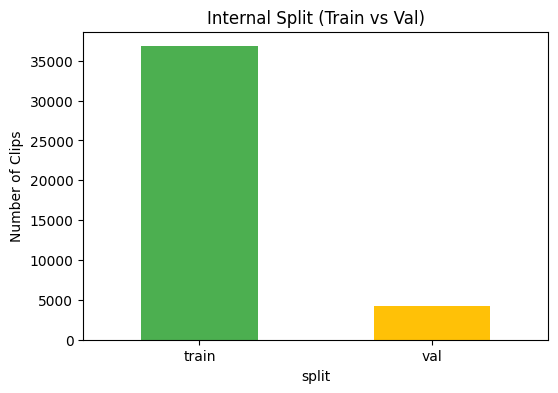

In [51]:
# Load ground truth
df_dev = pd.read_csv('/content/fsd50k_local/FSD50K.ground_truth/dev.csv')
# Check df_labels
print("--- Checking Columns in Ground Truth ---")
print(df_dev.columns.tolist())

split_counts = df_dev['split'].value_counts()
print(split_counts)

# Visualization
plt.figure(figsize=(6, 4))
split_counts.plot(kind='bar', color=['#4CAF50', '#FFC107'])
plt.title("Internal Split (Train vs Val)")
plt.ylabel("Number of Clips")
plt.xticks(rotation=0)
plt.show()

## **Ground Truth Label Cardinality Analysis**

This section analyzes the official Ground Truth metadata to determine the final label density used for model training. The results show an average of 2.79 labels per clip and a maximum of 18 concurrent labels.

/tmp/ipykernel_444/3347347562.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_dev, x='label_count', palette='magma')


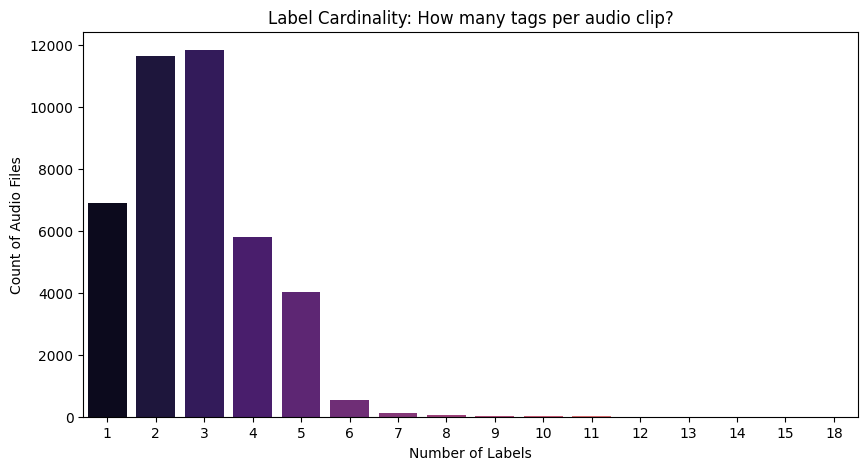

Average labels per clip: 2.79
Maximum labels in a single clip: 18


In [17]:

# Calculate number of labels per sample
df_dev['label_count'] = df_dev['labels'].apply(lambda x: len(x.split(',')))

# Visualization
plt.figure(figsize=(10, 5))
sns.countplot(data=df_dev, x='label_count', palette='magma')
plt.title("Label Cardinality: How many tags per audio clip?")
plt.xlabel("Number of Labels")
plt.ylabel("Count of Audio Files")
plt.show()

print(f"Average labels per clip: {df_dev['label_count'].mean():.2f}")
print(f"Maximum labels in a single clip: {df_dev['label_count'].max()}")

## **Audio Duration Distribution Analysis**
This section explores the temporal characteristics of the audio samples to define the input constraints for the deep learning model. By analyzing a representative sample of 2000 files, the results show a wide variance in length, ranging from a minimum of 0.30s to a maximum of 30.00s, with a mean duration of 7.09s. Since models like the Audio Spectrogram Transformer (AST) require fixed-size input tensors, these statistics are essential for determining the optimal global duration.

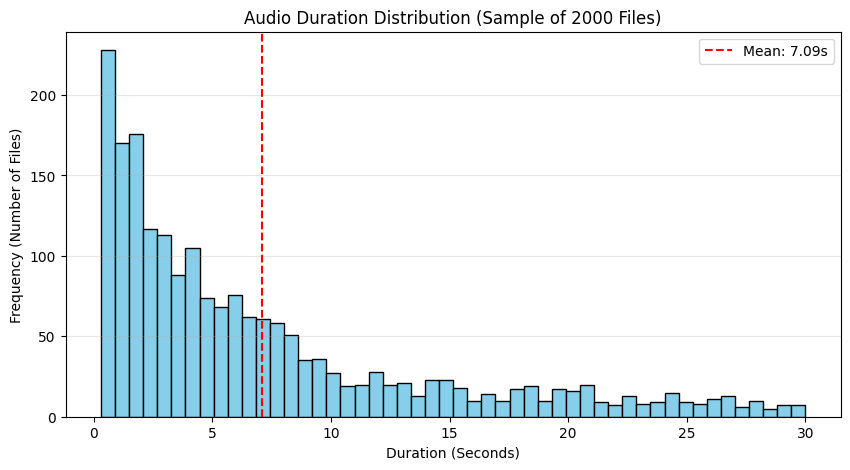

Minimum Duration: 0.30s
Maximum Duration: 30.00s
Mean Duration:    7.09s


In [11]:
# Setup paths
path_dev = "/content/fsd50k_local/FSD50K.dev_audio"
# Processing 2000 samples for a quick statistical overview
samples = os.listdir(path_dev)[:2000]

durations = []
for f in samples:
    # Get duration without loading the whole file into memory
    d = librosa.get_duration(path=os.path.join(path_dev, f))
    durations.append(d)

# Plotting the results
plt.figure(figsize=(10, 5))
plt.hist(durations, bins=50, color='skyblue', edgecolor='black')

# Calculate mean and add a reference line to the plot
mean_val = sum(durations)/len(durations)
plt.axvline(x=mean_val, color='red', linestyle='--', label=f"Mean: {mean_val:.2f}s")

plt.title("Audio Duration Distribution (Sample of 2000 Files)")
plt.xlabel("Duration (Seconds)")
plt.ylabel("Frequency (Number of Files)")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Print the final calculated duration metrics
print(f"Minimum Duration: {min(durations):.2f}s")
print(f"Maximum Duration: {max(durations):.2f}s")
print(f"Mean Duration:    {mean_val:.2f}s")

## **Ground Truth Class Frequency Analysis**
This section analyzes the official Ground Truth metadata to identify the most frequent sound classes. Unlike the raw metadata, the Ground Truth uses a hierarchical expansion based on the AudioSet ontology, resulting in a subset of 200 unique classes. The table below shows the top 20 most frequent classes, revealing a significant imbalance where generic categories like "Music" dominate the dataset. This frequency analysis is critical for preparing the model for a highly imbalanced multi-label environment.

Total Unique Classes: 200


/tmp/ipykernel_444/3306685115.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.head(20).values, y=label_counts.head(20).index, palette='viridis')


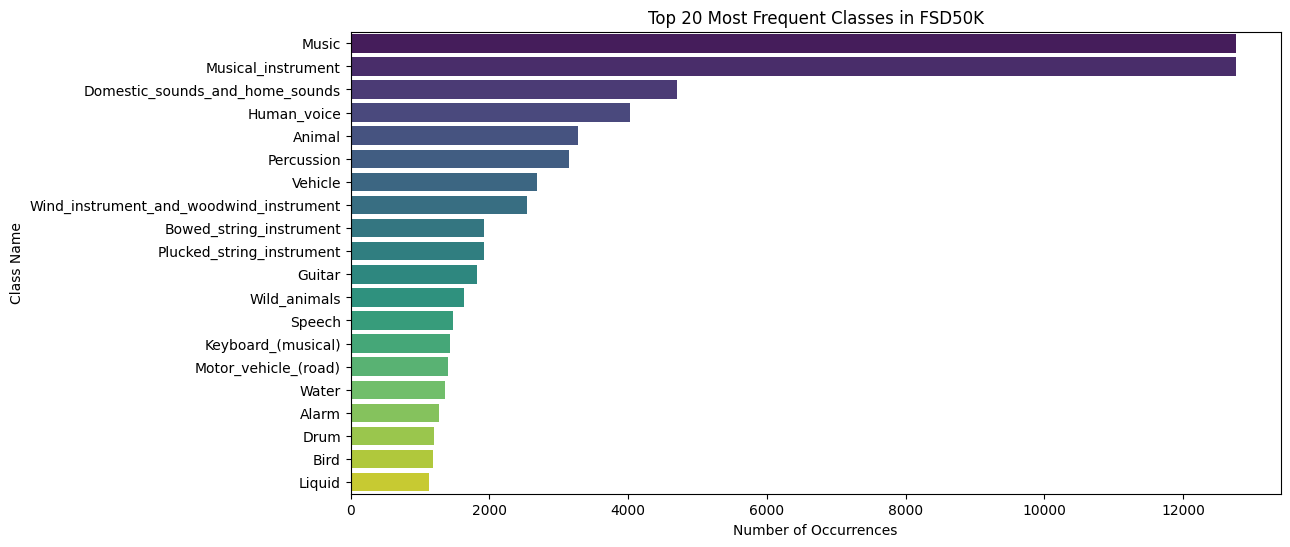

Total Unique Classes in Collection: 354


In [50]:
# Load the ground truth CSV
df_labels = pd.read_csv('/content/fsd50k_local/FSD50K.ground_truth/dev.csv')

# Split the multi-labels and flatten the list
all_labels = df_labels['labels'].str.split(',').explode()
label_counts = all_labels.value_counts()

print(f"Total Unique Classes: {len(label_counts)}")

# Plotting Top 20
plt.figure(figsize=(12, 6))
sns.barplot(x=label_counts.head(20).values, y=label_counts.head(20).index, palette='viridis')
plt.title("Top 20 Most Frequent Classes in FSD50K")
plt.xlabel("Number of Occurrences")
plt.ylabel("Class Name")
plt.show()


## **Audio Feature Visualization: Waveform and Mel-Spectrogram**

This section provides a qualitative look at the data by visualizing a random audio sample in both the time and frequency domains. The Waveform plot illustrates the sound's amplitude variations over time, revealing the temporal structure and dynamics of the signal. Below it, the Mel-Spectrogram represents the audio in the frequency domain, mapped to the Mel scale to mimic human auditory perception. By converting power to decibels (dB), we emphasize the spectral patterns that the Audio Spectrogram Transformer (AST) will use as primary features. This dual visualization is a crucial diagnostic step to ensure that the audio loading process is correct and that the spectral information is rich enough for deep learning feature extraction.

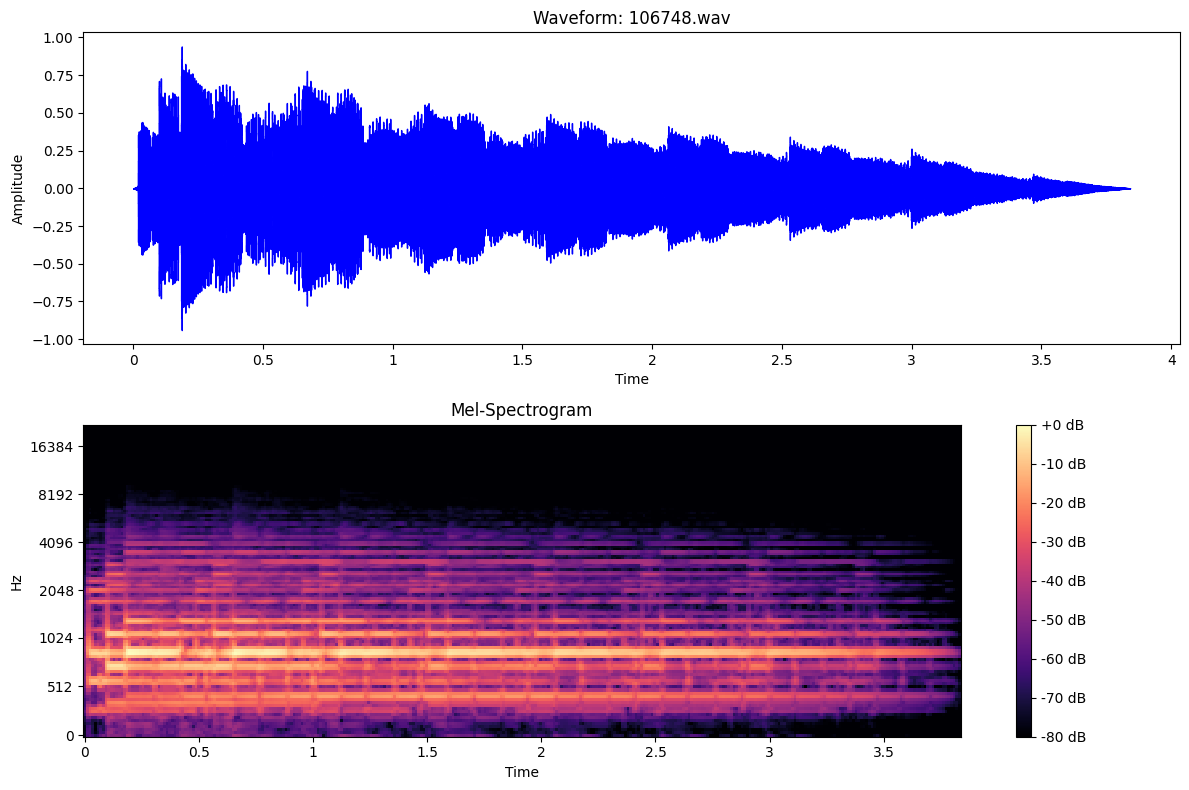

In [16]:
# Select a random file
random_file = random.choice(os.listdir(path_dev))
file_path = os.path.join(path_dev, random_file)

# Load audio
y, sr = librosa.load(file_path, sr=None)

# Create a figure with two subplots
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

# Waveform
librosa.display.waveshow(y, sr=sr, ax=ax[0], color='blue')
ax[0].set_title(f"Waveform: {random_file}")
ax[0].set_ylabel("Amplitude")

# Mel-Spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)
img = librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=ax[1])
ax[1].set_title("Mel-Spectrogram")
fig.colorbar(img, ax=ax[1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

## **Sampling Rate Consistency Analysis**
This section evaluates the sampling rate across the dataset to ensure that the digital representation of the audio signals is uniform. After inspecting a representative subset of 500 files, the results indicate that all samples are consistent at 44,100 Hz. This uniformity is critical for spectral analysis, as the frequency resolution of a Mel-spectrogram depends directly on the sampling rate. Since no mixed sampling rates were detected, the preprocessing pipeline is simplified, as it will not require a resampling stage.

In [20]:
path_dev = "/content/fsd50k_local/FSD50K.dev_audio"
sample_files = os.listdir(path_dev)[:500] # Checking 500 files
sr_list = []

print("Checking Sampling Rates...")
for f in tqdm(sample_files):
    curr_sr = librosa.get_samplerate(os.path.join(path_dev, f))
    sr_list.append(curr_sr)

sr_series = pd.Series(sr_list)
print("\nSampling Rate Distribution:")
print(sr_series.value_counts())

if len(sr_series.unique()) > 1:
    print("\n WARNING: Mixed sampling rates detected! You must resample during preprocessing.")
else:
    print(f"\n All files are consistent at {sr_series.unique()[0]} Hz.")

Checking Sampling Rates...


100%|██████████| 500/500 [00:00<00:00, 10371.83it/s]


Sampling Rate Distribution:
44100    500
Name: count, dtype: int64

✅ All files are consistent at 44100 Hz.


## **Class Co-occurrence and Hierarchical Correlation**

This section analyzes the semantic relationships between the top 25 classes using a co-occurrence matrix. The heatmap visually confirms the hierarchical nature of the AudioSet ontology; for instance, the intense correlation between Music and Musical_instrument, or Plucked_String_Instrument and Guitar, demonstrates that these labels are systematically assigned together. Identifying these clusters is crucial for understanding how the model might leverage label dependencies during training.

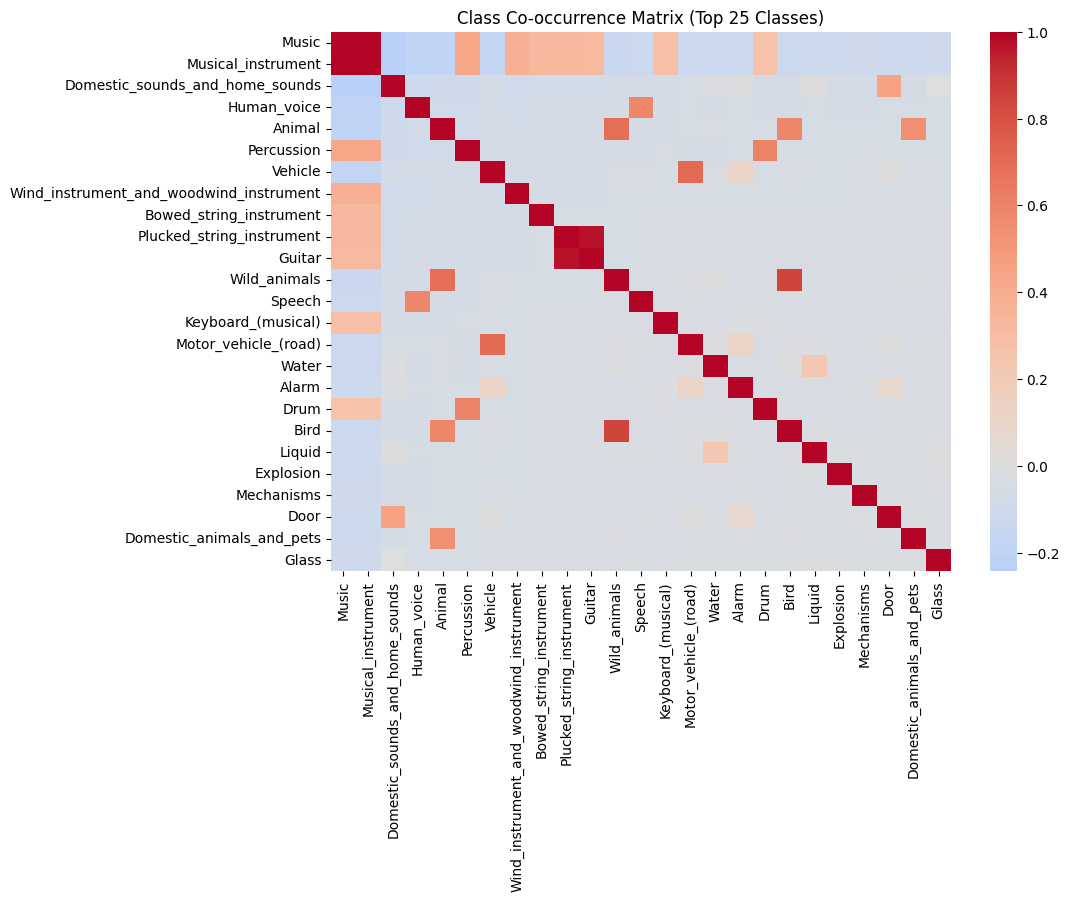

In [24]:
# Prepare labels for binarization
labels_split = df_dev['labels'].str.split(',')
mlb = MultiLabelBinarizer()
binary_labels = mlb.fit_transform(labels_split)

# Create a DataFrame with binary columns for each class
df_binary = pd.DataFrame(binary_labels, columns=mlb.classes_)

# Select only the Top 25 classes for the heatmap (to keep it readable)
top_25_classes = df_binary.sum().sort_values(ascending=False).head(25).index
correlation_matrix = df_binary[top_25_classes].corr()

# Plot Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Class Co-occurrence Matrix (Top 25 Classes)")
plt.show()

## **Class Pruning and Threshold Impact Analysis**

This section address the "Long Tail" distribution problem inherent in the FSD50K dataset. In multi-label audio classification, many classes have very few samples, which can lead to overfitting, as the model might simply memorize those specific clips instead of learning general acoustic features. By testing different sample size thresholds ($t$), we evaluate the trade-off between taxonomic diversity and statistical robustness. Establishing a minimum threshold (e.g., $t=100$) allows us to prune infrequent classes, ensuring that the Audio Spectrogram Transformer (AST) is trained only on categories with enough data to achieve meaningful generalization.

In [54]:
# 1. PREPARATION: Extract frequencies from the official Ground Truth
# We 'explode' the multi-label strings to count each official class individually
gt_label_series = df_dev['labels'].str.split(',').explode().str.strip()
gt_counts = gt_label_series.value_counts()

def check_threshold_impact(counts, thresholds):
    """
    Analyzes how many of the 200 official Ground Truth classes are kept
    based on different sample size thresholds.
    """
    TOTAL_OFFICIAL_CLASSES = 200

    print(f"{'Threshold':<12} | {'Classes Kept (of 200)':<22} | {'Classes Lost':<15}")
    print("-" * 55)

    for t in thresholds:
        # Count how many official classes exceed the sample threshold 't'
        kept = len(counts[counts >= t])
        lost = TOTAL_OFFICIAL_CLASSES - kept
        print(f"{t:<12} | {kept:<22} | {lost:<15}")

# 2. EXECUTION: Evaluate impact on the 200 real target classes
thresholds_to_test = [20, 50, 100, 150, 200]
check_threshold_impact(gt_counts, thresholds_to_test)

Threshold    | Classes Kept (of 200)  | Classes Lost   
-------------------------------------------------------
20           | 200                    | 0              
50           | 200                    | 0              
100          | 165                    | 35             
150          | 142                    | 58             
200          | 113                    | 87             


## **Audio Intensity Analysis (RMS Energy)**
This section evaluates the average power of the audio signals by calculating their Root Mean Square (RMS) energy. Unlike peak amplitude, RMS provides a better representation of the perceived loudness of a sound. The generated histogram reveals a distribution heavily skewed towards low energy levels (0.0 - 0.1), with a sparse "long tail" of high-intensity samples. This variance indicates that the dataset contains significant volume fluctuations. To ensure the Audio Spectrogram Transformer (AST) focuses on acoustic patterns rather than arbitrary gain differences, a global normalization step will be implemented during preprocessing to standardize the dynamic range across all samples.

Calculating RMS: 100%|██████████| 500/500 [00:04<00:00, 122.25it/s]


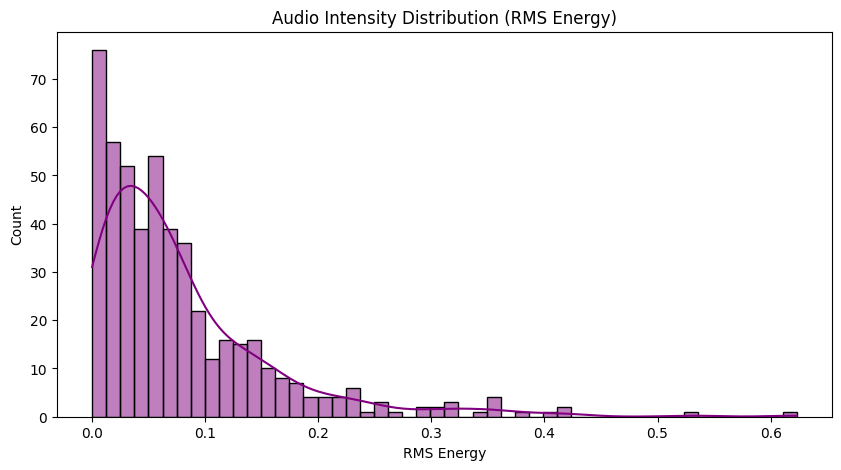

Mean RMS: 0.0780


In [46]:
rms_values = []
# We use the same 500 samples as before for speed
for f in tqdm(sample_files, desc="Calculating RMS"):
    y, _ = librosa.load(os.path.join(path_dev, f), sr=None)
    rms = np.sqrt(np.mean(y**2))
    rms_values.append(rms)

# Visualize the distribution of loudness
plt.figure(figsize=(10, 5))
sns.histplot(rms_values, bins=50, kde=True, color="purple")
plt.title("Audio Intensity Distribution (RMS Energy)")
plt.xlabel("RMS Energy")
plt.ylabel("Count")
plt.show()

print(f"Mean RMS: {np.mean(rms_values):.4f}")

## **Correlation Analysis: Audio Duration vs. Label Density**
This section investigates whether the temporal length of an audio clip influences its semantic complexity. By plotting the duration against the number of labels, we observe a very low correlation. The scatter plot shows horizontal clusters (strips) at discrete label counts, indicating that short clips (under 5s) can be as complex as long recordings (30s). This finding is crucial for the training strategy: the model cannot rely on duration as a proxy for complexity and must be capable of extracting high-density information from very short acoustic windows.

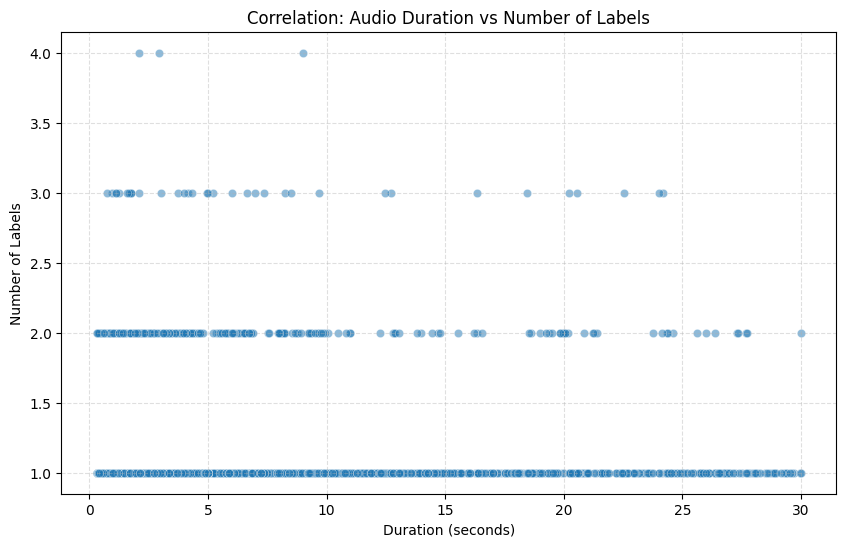

Pearson Correlation: 0.0031


In [52]:
# Aligning the durations list with the subset of the dataframe
sample_fnames = [s.replace('.wav','') for s in samples]
df_subset = dev[dev['fname'].astype(str).isin(sample_fnames)].copy()

plt.figure(figsize=(10, 6))
# Using the 'durations' list from the previous Audio Duration Analysis
sns.scatterplot(x=durations, y=df_subset['num_labels'][:len(durations)], alpha=0.5)

plt.title("Correlation: Audio Duration vs Number of Labels")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Labels")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# Calculating the Pearson correlation coefficient
corr_val = pd.Series(durations).corr(df_subset['num_labels'][:len(durations)].reset_index(drop=True))
print(f"Pearson Correlation: {corr_val:.4f}")

## **EDA Summary & Final Engineering Insights**

This section synthesizes all the findings from the Exploratory Data Analysis into a single, actionable summary. The code extracts real-time metrics from the Ground Truth metadata to define the constraints of the preprocessing pipeline. By setting a pruning threshold ($t=100$), we ensure that only statistically robust classes are used, preventing the model from failing on rare categories. Furthermore, it documents the transition from raw audio (44.1 kHz) to the standardized input required by the Audio Spectrogram Transformer (16 kHz, 128 Mel bins, and 10s duration). This table serves as the technical bridge between data discovery and model implementation.

In [53]:

threshold = 100
all_labels = df_dev['labels'].str.split(',').explode()
label_counts = all_labels.value_counts()
kept_labels = label_counts[label_counts >= threshold]

stats = {
    "Total Raw Classes": len(label_counts),
    "Classes Kept (t>=100)": len(kept_labels),
    "Training Samples": df_dev[df_dev['split'] == 'train'].shape[0],
    "Validation Samples": df_dev[df_dev['split'] == 'val'].shape[0],
    "Mean Duration": 7.09,  # Resultado de tu análisis anterior
    "Sampling Rate": "44,100 Hz -> Resample to 16,000 Hz"
}


summary_table = f"""
### **Final EDA Summary & Engineering Insights**

| Metric | Value | Decision / Action |
| :--- | :--- | :--- |
| **Class Pruning** | {stats['Classes Kept (t>=100)']} classes (from {stats['Total Raw Classes']}) | Filter labels with <{threshold} samples to avoid overfitting. |
| **Data Partition** | {stats['Training Samples']} Train / {stats['Validation Samples']} Val | Use official splits for benchmark consistency. |
| **Audio Frequency** | {stats['Sampling Rate']} | Resample to 16kHz for AST model compatibility. |
| **Temporal Window** | {stats['Mean Duration']}s avg (Max 30s) | Apply padding/truncation to a fixed 10s buffer. |
| **Input Feature** | Mel-Spectrogram (128 bins) | Convert waveforms to spectral images for the Transformer. |
| **Loss Function** | Multi-label (Binary Cross Entropy) | Handle hierarchical and overlapping labels. |
"""

from IPython.display import Markdown
display(Markdown(summary_table))


### **Final EDA Summary & Engineering Insights**

| Metric | Value | Decision / Action |
| :--- | :--- | :--- |
| **Class Pruning** | 165 classes (from 200) | Filter labels with <100 samples to avoid overfitting. |
| **Data Partition** | 36796 Train / 4170 Val | Use official splits for benchmark consistency. |
| **Audio Frequency** | 44,100 Hz -> Resample to 16,000 Hz | Resample to 16kHz for AST model compatibility. |
| **Temporal Window** | 7.09s avg (Max 30s) | Apply padding/truncation to a fixed 10s buffer. |
| **Input Feature** | Mel-Spectrogram (128 bins) | Convert waveforms to spectral images for the Transformer. |
| **Loss Function** | Multi-label (Binary Cross Entropy) | Handle hierarchical and overlapping labels. |
